The library has methods for managing projects, import sessions, annotate video as time series of events, 

In [37]:
# import the library 
from behavex.project import Project
from pathlib import Path
from IPython.display import HTML, display, Image

#### Plotting  Helper

In [29]:
def show_plots(project, session_id=None):
    """Display saved plots for a project/session"""
    from IPython.display import Image, display
    
    # Loss history
    plots_dir = project.project_dir / "plots"
    loss_files = sorted(plots_dir.glob("loss_history_*.png"))
    if loss_files:
        print("Loss History:")
        display(Image(str(loss_files[-1])))
    
    # Validation plots
    if session_id:
        session = next(s for s in project.sessions if s.id == session_id)
        val_dir = session.session_root / "validation"
        val_plots = sorted(val_dir.glob("*.png"))
        for plot in val_plots:
            print(f"\n{plot.name}:")
            display(Image(str(plot)))

## Project and Data Management 

In [2]:
# project management 
project_dir_root = Path("/users/thomasbush/Downloads") / "tutorial_rearing"
# we create the project by specifying the project directory and name
project = Project(project_dir=str(project_dir_root), project_name="tutorial")

A project directory is initialized with only two components:
- config.yaml, which contains all the arguments 
- sessions.yaml, which contains the sessions information

The config file can easily be update by either using the .set_config_value to change a single value or with a deeper update with .edit_config

In [3]:
project.set_config_value("data.window_size", 40)
updates = {
    "data": {
        "window_size": 40,
        "fps": 60,
    },
    "model_defaults": {
        "training": {
            "epochs": 30,
            "batch_size": 32,
        }
    },
}
project.edit_config(updates)
project.show_config()

annotation:
  annotator: ''
  behavior: rearing
  output_format: csv
data:
  feature_set:
  - height
  - forepaw_tail_distance
  - height_displacement
  - trunk_speed
  fps: 60
  window_size: 40
debug:
  save_intermediate: false
  verbose: false
model_defaults:
  inference:
    smoothing: true
    smoothing_window: 5
  model_name: gru
  training:
    batch_size: 32
    device: mps
    epochs: 30
    hidden_size: 16
    lr: 0.001
    patience: 5
    save_model: true
    save_path: /users/thomasbush/Downloads/tutorial_rearing/models
    test_every_n_epochs: 1
    verbose: false
    weight_decay: 1.0e-05
paths:
  keypoints_root: ''
  video_root: ''
project:
  description: ''
  name: tutorial
  version: '1.0'



Sessions can be added to a project by using the add_session method

In [4]:
session_path = Path(
    "/Users/thomasbush/Downloads/multicam_video_2025-05-07T12_16_20_cropped-v2_20250701121021"
)
# This automatically:
#   - detects the 5 camera files
#   - maps them to views (central, bottom, left, right, top)
#   - adds metadata to sessions.yaml
#   - creates Session object
#   - creates folder: project_dir/sessions/session_XXX/
session = project.add_session(session_path)
print(f"\nAdded session: {session.id}")
print("Views detected:", list(session.views.keys()))
print("Annotation view:", session.annotation_view)
print("Annotation file expected at:", session.annotation_path())
print("Feature file path:", session.features_path())

Session with path '/Users/thomasbush/Downloads/multicam_video_2025-05-07T12_16_20_cropped-v2_20250701121021' already exists (ID: 'session_001'). Merging views.
Updated session session_001 with merged views.

Added session: session_001
Views detected: ['bottom', 'right', 'central', 'top', 'left']
Annotation view: bottom
Annotation file expected at: /users/thomasbush/Downloads/tutorial_rearing/sessions/multicam_video_2025-05-07T12_16_20_cropped-v2_20250701121021/session_001_annotations.csv
Feature file path: /users/thomasbush/Downloads/tutorial_rearing/sessions/multicam_video_2025-05-07T12_16_20_cropped-v2_20250701121021/session_001_features.csv


We can view all the sessions in the project by accessing them through the .sessions method

In [5]:
print("\nAll sessions in project:")
for sess in project.sessions:
    print(" -", sess.id, "at", sess.video_dir)


All sessions in project:
 - session_001 at /Users/thomasbush/Downloads/multicam_video_2025-05-07T12_16_20_cropped-v2_20250701121021


## Annotation

Annotations can be done using two methods:

- ```Project.annotate_sessions()``` which opens a dialog to select the session, it launcges the annotation tool for the selected session. 
- Using  ```from behavex.annotation.pavs import start_app```, you can annotate single session 

Predictions can be made by pressing "h" to start the event and "j" to stop it. On the side it is possible to visualize the events. If clicked on a event the video will jump to it to review it. 

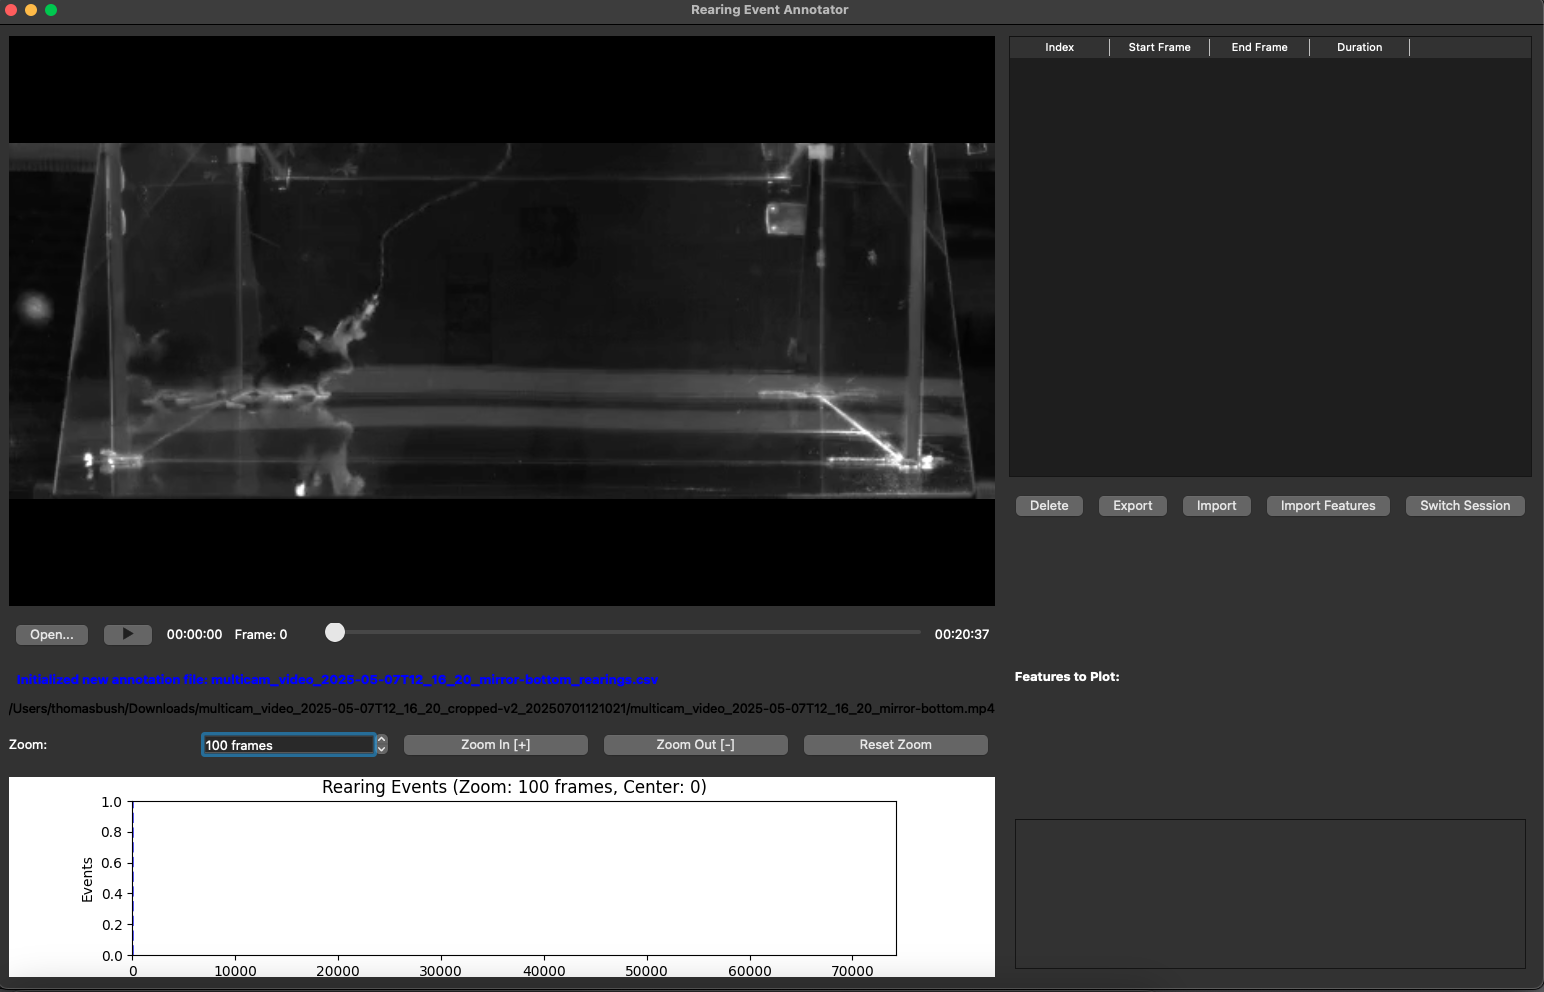

In [38]:
# sample image for the GUI
Image(filename="/Users/thomasbush/Documents/images_for_behavex/GUI.png")

In [17]:
project.annotate_sessions()

2025-11-23 17:45:13.565 python[46515:395542031] +[IMKClient subclass]: chose IMKClient_Modern
2025-11-23 17:45:13.565 python[46515:395542031] +[IMKInputSession subclass]: chose IMKInputSession_Modern


Starting annotation for session session_001 (bottom view)...


2025-11-23 17:46:30.450 python[46515:395542031] _TIPropertyValueIsValid called with 16 on nil context!
2025-11-23 17:46:30.450 python[46515:395542031] imkxpc_getApplicationProperty:reply: called with incorrect property value 16, bailing.
2025-11-23 17:46:30.450 python[46515:395542031] Text input context does not respond to _valueForTIProperty:
2025-11-23 17:46:49.917 python[46515:395542031] _TIPropertyValueIsValid called with 16 on nil context!
2025-11-23 17:46:49.917 python[46515:395542031] imkxpc_getApplicationProperty:reply: called with incorrect property value 16, bailing.
2025-11-23 17:46:49.917 python[46515:395542031] Text input context does not respond to _valueForTIProperty:


: 

Once you have closed the annotator, you will receive an error, but that's fine. 
Another option is to load the events by

In [7]:
project.sessions[0].load_annotations()

In [8]:
# after loading you can easily inspect the labels, which are stored in a .csv: 
project.sessions[0].annotations.head()

,index,start_frame,end_frame,duration
0,1,8375,8396,21
1,2,8728,8781,53
2,3,9144,9228,84
3,4,11052,11069,17
4,5,17772,17858,86


## Load and Select Training Features

The library also offers an option to load external features that you can use to train a model and to predict the desired behavior. 

Note: you only have to load your features once, then they are going to saved in the project directory for further uses. 

In [7]:
project.import_features_for_session(
    session_id=session.id,
    features_path = Path("/Users/thomasbush/Downloads/shared WithTWB/m002_s001_cricket.xlsx"),

)
print(project.sessions[0].features_file())
print(project.sessions[0].events_file())

Imported 31 features (74269 frames) from m002_s001_cricket.xlsx to /users/thomasbush/Downloads/tutorial_rearing/sessions/multicam_video_2025-05-07T12_16_20_cropped-v2_20250701121021/session_001_features.csv
/users/thomasbush/Downloads/tutorial_rearing/sessions/multicam_video_2025-05-07T12_16_20_cropped-v2_20250701121021/session_001_features.csv
/Users/thomasbush/Downloads/multicam_video_2025-05-07T12_16_20_cropped-v2_20250701121021/multicam_video_2025-05-07T12_16_20_mirror-bottom.csv


Before launching the training, it is a good practice to inspect the labels and features together, that can be done by launching ```project.annotate_sessions()``` and then plotting the desidred features with the video and labels. 

Once we have selected the best features to use for the training, we can update the config:

Note: currently the library does not create the features from the tracking data, but it will in the future

In [9]:
project.set_config_value("data.feature_set", ["height", "forepaw_tail_distance", "height_displacement","trunk_speed"])
print(project.config["data"]["feature_set"])
project.select_features()

['height', 'forepaw_tail_distance', 'height_displacement', 'trunk_speed']


Once the features are selected, we can convert the annotations to labels (0, 1) and plot them

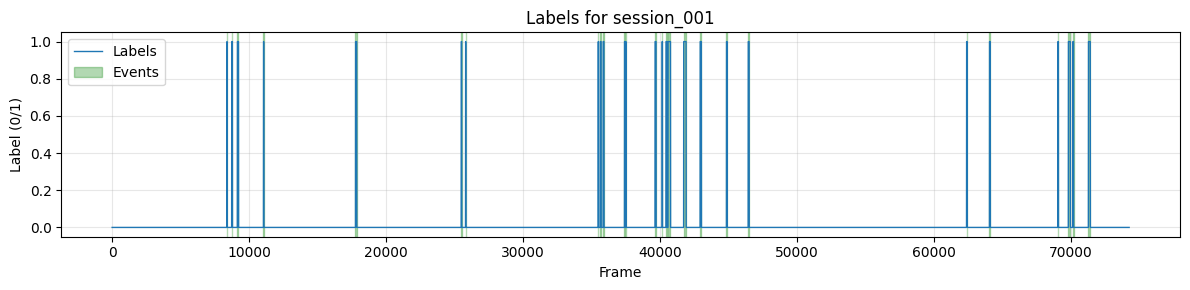

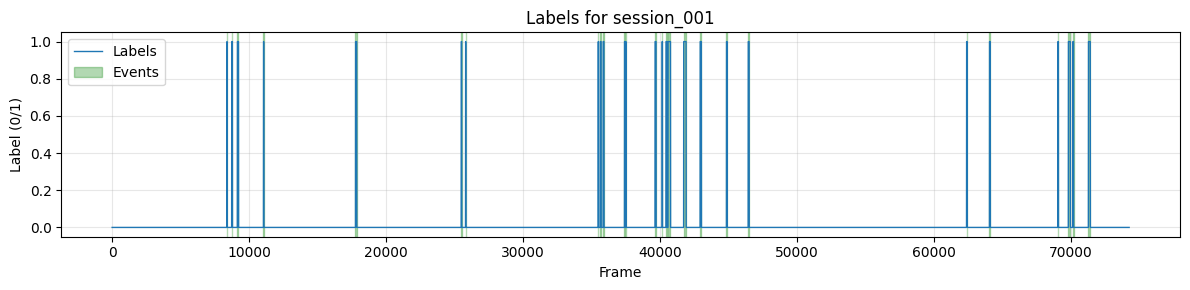

In [13]:
import matplotlib
matplotlib.use('inline')  # or 'notebook' for interactive
%matplotlib inline

project.sessions[0].build_labels()

from IPython.display import display
fig = session.plot_labels()
display(fig)

We can see the whole time series and in blue the events for our session. 

## Model Training 

Then we can prepare the data for training by:
- ```build_windows```: it creates the temporal windows needed to train recurrent models (30 by defualt), for each frame t, it takes a window t-w of frames as input of the model-> shape (TOT_FRAMES, W, D), where W is the window_size and d is the features dimenion. 
- split the data into validation and train, where validation preserves the temporal order as it takes a continous middle chunk of the series (default=10%)
- ```subsample_session```: it sumsample the training data to belance the positive and negative events (default is 1:1). After sampling, it shuffle the data
- ```merge_and_generate_training_data```: it combines all the data between sessions

In [24]:
project.sessions[0].build_windows()
print(project.sessions[0].windows.shape)
# Split temporally FIRST (before subsampling)
project.sessions[0].split_data()
print(project.sessions[0].train_windows.shape)
print(project.sessions[0].train_labels.shape)
print(project.sessions[0].val_windows.shape)
print(project.sessions[0].val_labels.shape)
# Then subsample only training data
project.sessions[0].subsample_session()
print(project.sessions[0].train_windows.shape)
print(project.sessions[0].train_labels.shape)
project.merge_and_generate_training_data()
print(project.train_windows.shape)
print(project.train_labels.shape)

(74269, 30, 4)
(66842, 30, 4)
(66842,)
(7427, 30, 4)
(7427,)
(3631, 30, 4)
(3631,)
(3631, 30, 4)
(3631,)


Before the training, we can set the training parameters by accessing to the ```config.model_defaults```

In [18]:
for key, value in project.config["model_defaults"].items():
    if key == "training":
        for k, v in value.items():
            print(f"{k}: {v}")
        continue
    print(f"{key}: {value}")

inference: {'smoothing': True, 'smoothing_window': 5}
model_name: gru
batch_size: 32
device: mps
epochs: 30
hidden_size: 16
lr: 0.001
patience: 5
save_model: True
save_path: /users/thomasbush/Downloads/tutorial_rearing/models
test_every_n_epochs: 1
verbose: False
weight_decay: 1e-05


We can update the training parameters with the usual ```set_config_value``` method: 


Note: at the moment, the only model used is a Gated Recurrent Neural Network with Binary Cross Entropy loss but the library is thought to support more models in the future

In [25]:
project.set_config_value("model_defaults.training.epochs", 10)

Once the data and parameters are set, you can launch the training using ```project.train```. The method will automatically: 
- train the moodel
- launch tensorboard to check the performances
- save the model and the scaler applied to the features
- save plots of: loss and validation data (every 5 epochs by default)

In [26]:
project.train()


TensorBoard started at: http://localhost:6006
Log directory: /users/thomasbush/Downloads/tutorial_rearing/models/runs

Epoch 1/10 - Train Loss: 0.5912 | Test Loss: 0.3802
Epoch 2/10 - Train Loss: 0.1935 | Test Loss: 0.1486
Epoch 3/10 - Train Loss: 0.1284 | Test Loss: 0.1386
Epoch 4/10 - Train Loss: 0.1134 | Test Loss: 0.1268
Epoch 5/10 - Train Loss: 0.1047 | Test Loss: 0.1147
Session session_001 - Validation: 7427 frames, 583.0 positive labels
Epoch 6/10 - Train Loss: 0.0950 | Test Loss: 0.1124
Epoch 7/10 - Train Loss: 0.0895 | Test Loss: 0.1071
Epoch 8/10 - Train Loss: 0.0856 | Test Loss: 0.1050
Epoch 9/10 - Train Loss: 0.0828 | Test Loss: 0.1024
Epoch 10/10 - Train Loss: 0.0805 | Test Loss: 0.1041
Session session_001 - Validation: 7427 frames, 583.0 positive labels
Model saved: /users/thomasbush/Downloads/tutorial_rearing/models/models/gru_h16_e10_20251123_184215.pth
Metadata saved: /users/thomasbush/Downloads/tutorial_rearing/models/models/gru_h16_e10_20251123_184215_metadata.json


We can visualize the results by plotting them

Loss History:


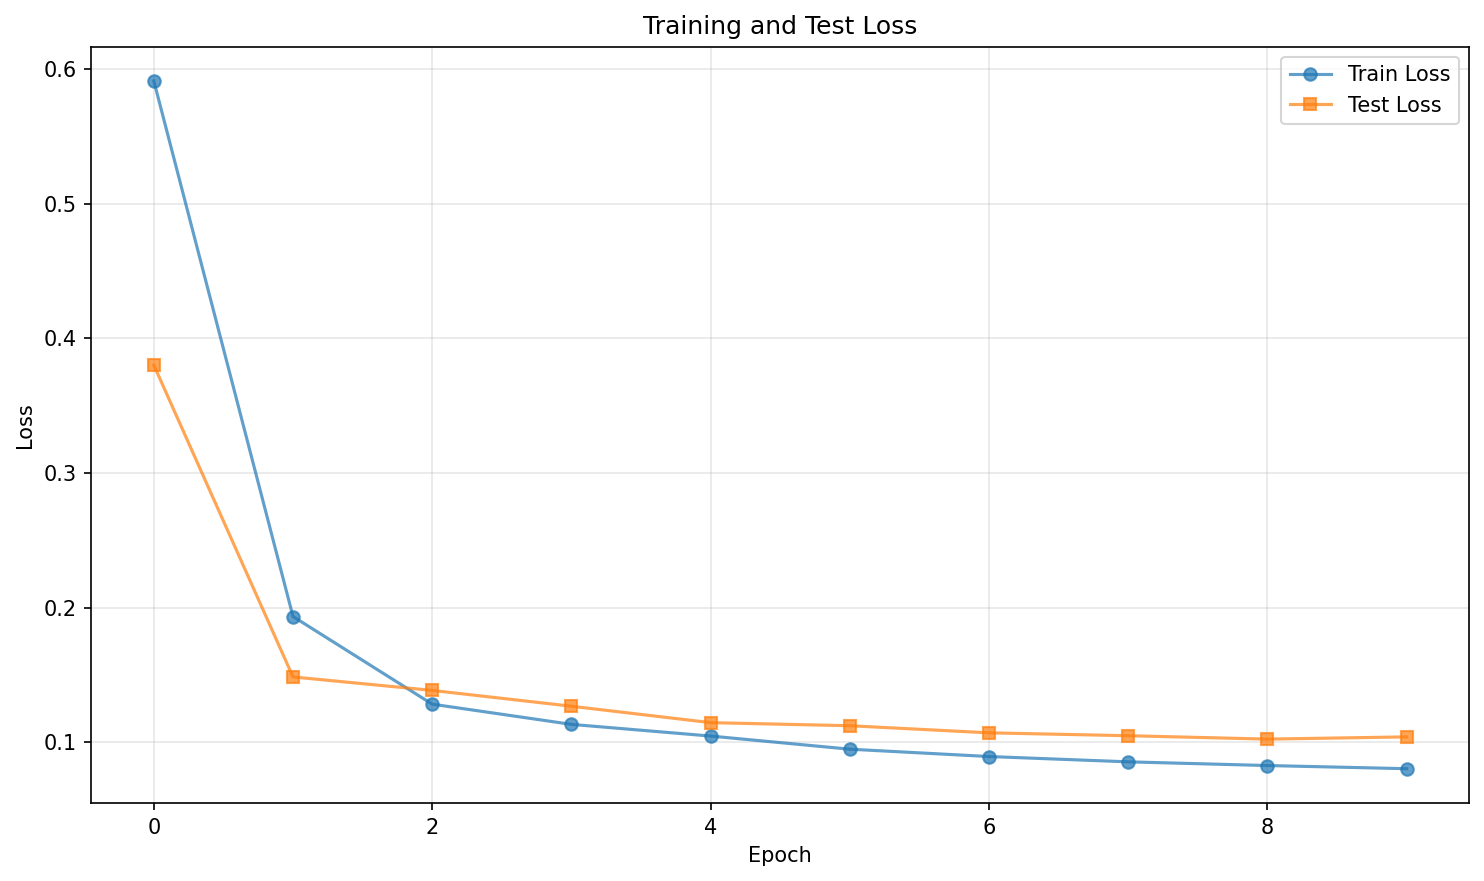


session_001_10_validation.png:


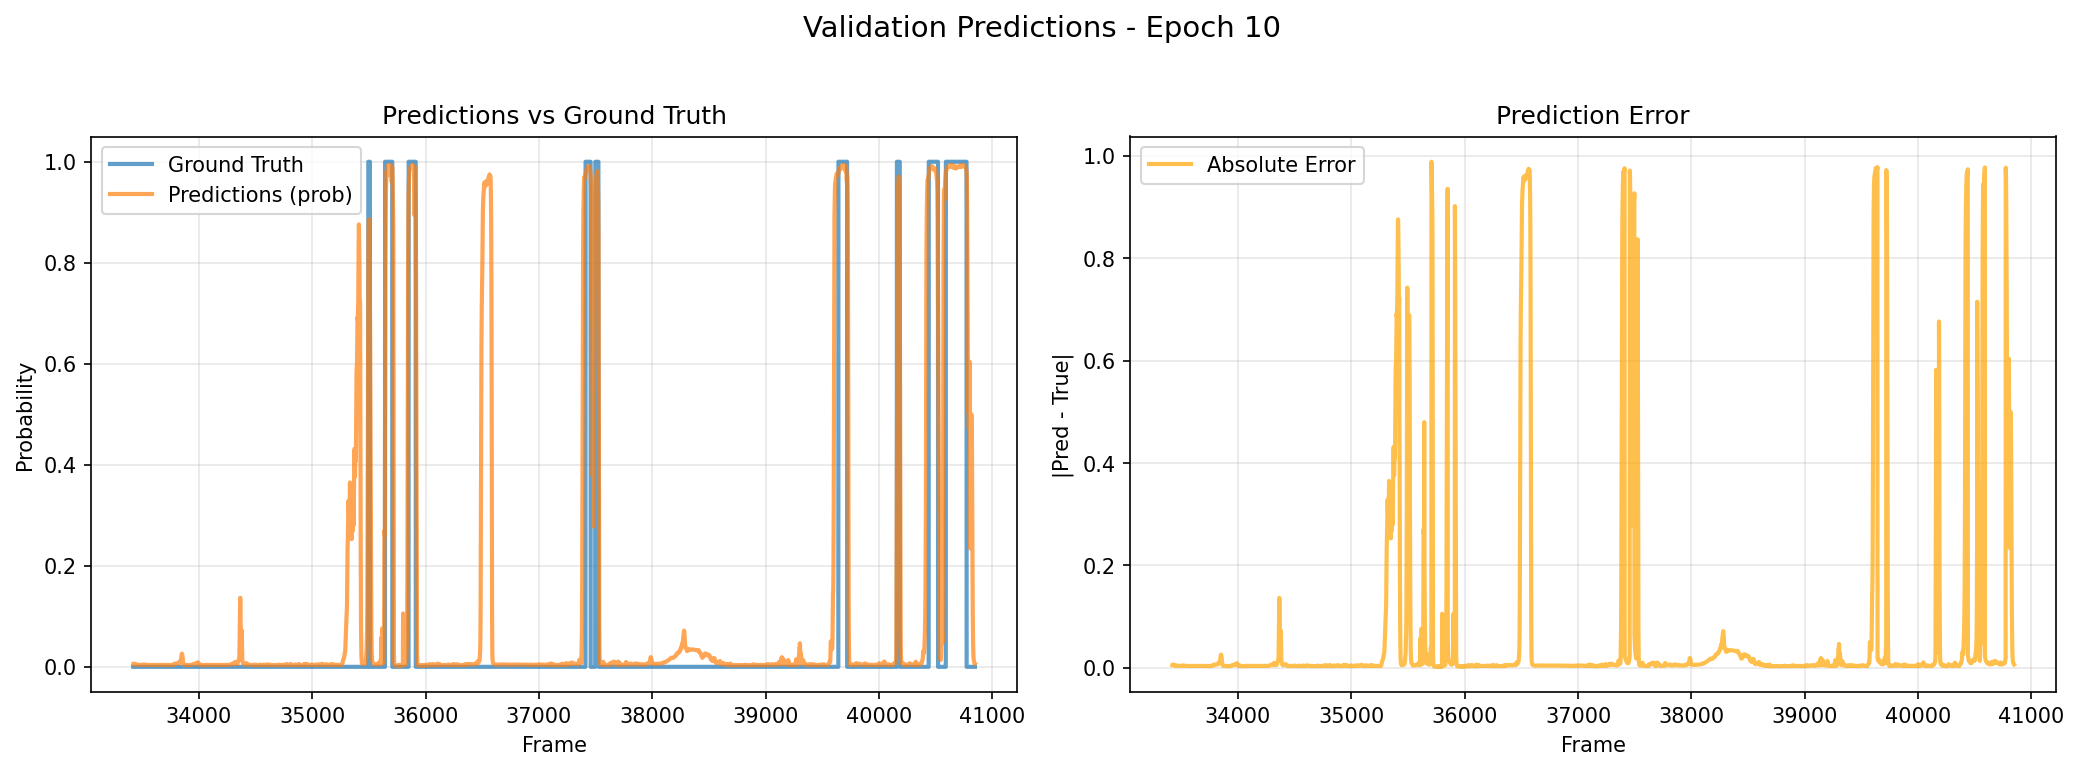


session_001_5_validation.png:


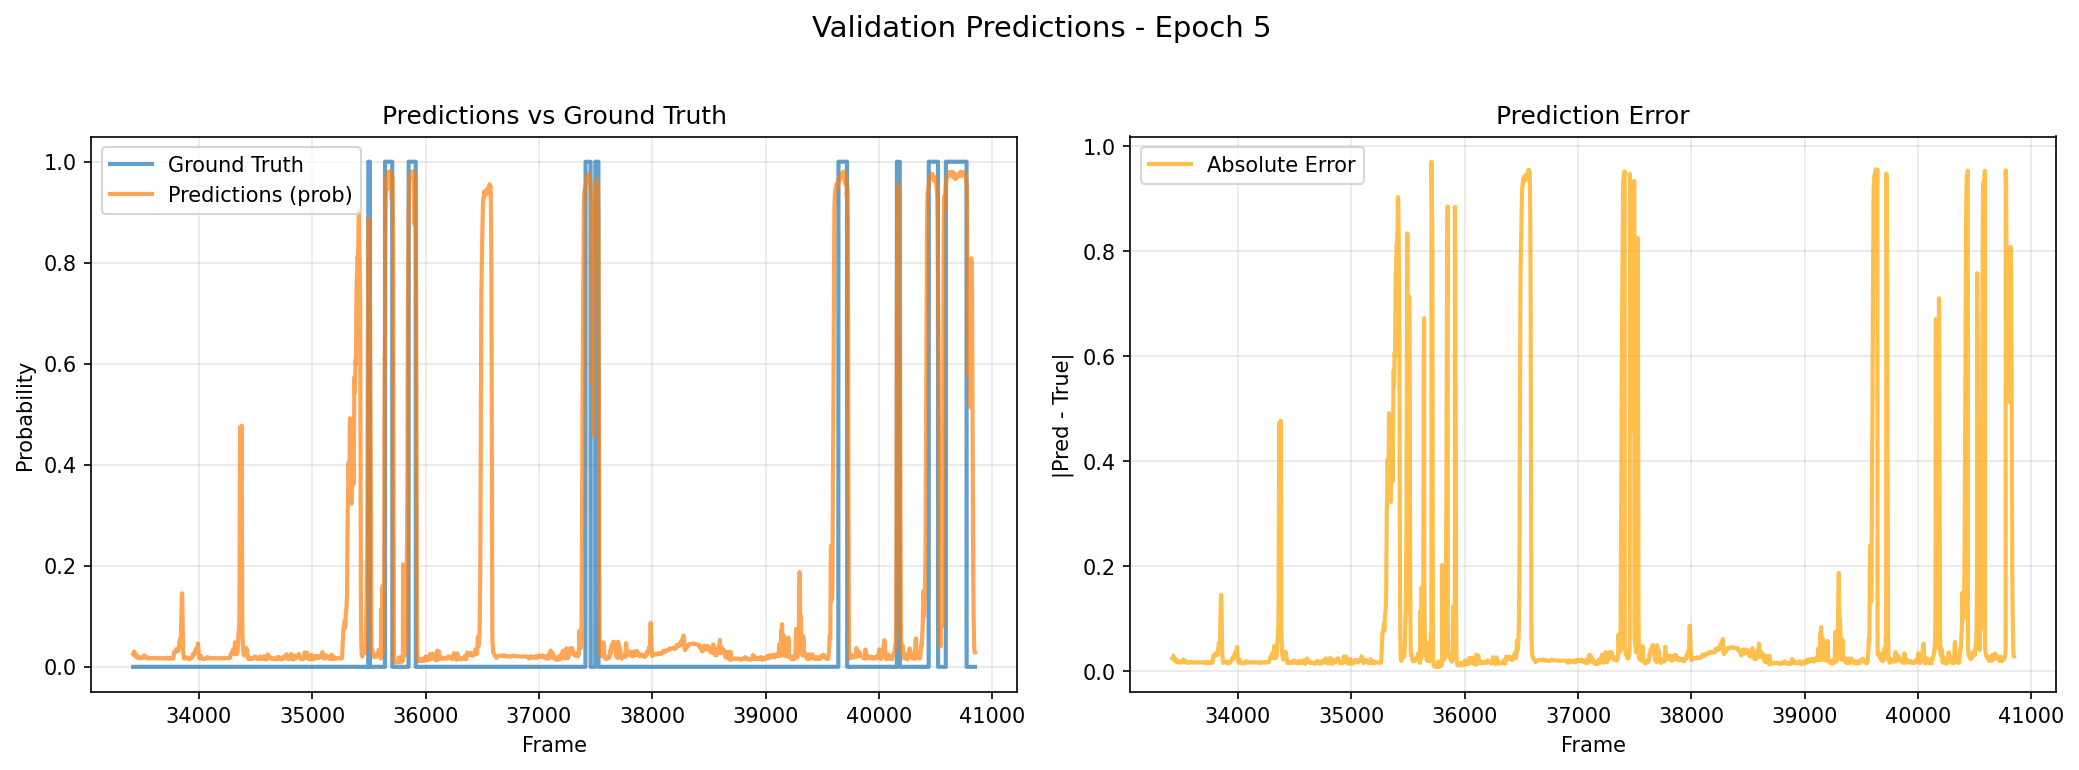

In [30]:
# we can plot the images generate
# Usage
show_plots(project, "session_001")

## Predict Over New Data

Once you are satisfied with the performances of a model. You can simply run it over new data to extract the predicted events by importing the sessions that you want to predict on. Then the libray will: 
- Prepare the data: builds sliding windows, scales features-> tot_frames, window_size, num_features
- Model loading: loads the trained weights, reconstructs the model
- Model Warm-up: runs a dummy forward pass to trigger ```torch.compile``` to speed up the predictions 
- Run a batch prediction over the whole series
- Maps probabilities to events and creates a df of events like the annotations
- Saves teh results: {session_id}_pred.csv and an interactive plot as {session_id}_interactive.html with probabilities and events. 

In [27]:
# test over the first session to show
project.sessions_to_predict = [project.sessions[0].id]
results = project.predict(threshold=0.8)
print(f"Predictions shape for {project.sessions[0].id}: {results[project.sessions[0].id].shape}")

Scaler loaded: /users/thomasbush/Downloads/tutorial_rearing/models/scalers/scaler_gru_h16_e10_20251123_184215.pkl
Model loaded: /users/thomasbush/Downloads/tutorial_rearing/models/models/gru_h16_e10_20251123_184215.pth
Model warmed up with shape: (64, 40, 4)
Predicting on session: session_001
Predictions saved: /users/thomasbush/Downloads/tutorial_rearing/sessions/multicam_video_2025-05-07T12_16_20_cropped-v2_20250701121021/predictions/session_001_pred.csv
Interactive plot saved: /users/thomasbush/Downloads/tutorial_rearing/sessions/multicam_video_2025-05-07T12_16_20_cropped-v2_20250701121021/predictions/session_001_interactive.html
Predictions shape for session_001: (74269,)


We can display the predicted probability to adjust the threshold for the events

In [32]:
from IPython.display import HTML

# Read and display HTML
html_path = project.sessions[0].session_root / "predictions" / "session_001_interactive.html"
with open(html_path, 'r') as f:
    html_content = f.read()
HTML(html_content)